# Appendix — 4D-Var with a 1-D advection–diffusion model

A compact twin experiment showing the forward model, hand-written adjoint gradient,
gradient verification, and optimization of the initial condition.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(0)

## 1. Forward model and twin experiment

The linear model advances the state as \(x_{n+1}=Ax_n\). Sparse noisy observations are generated from a known trajectory, and 4D-Var starts from a deliberately wrong background state.

In [2]:
N = 100
L = 1.0
dx = L / N
u = 1.0
kap = 2e-3
dt = 0.4 * dx / u
M = 120

ca = u * dt / dx
cd = kap * dt / dx**2

A = np.zeros((N, N))
for i in range(N):
    A[i, i] += 1 - ca - 2*cd
    A[i, (i - 1) % N] += ca + cd
    A[i, (i + 1) % N] += cd

def forward_model(x0):
    traj = np.empty((M + 1, N))
    traj[0] = x0
    for n in range(M):
        traj[n + 1] = A @ traj[n]
    return traj

xgrid = np.linspace(0, L, N, endpoint=False)

# Twin-experiment truth
x0_true = np.exp(-0.5 * ((xgrid - 0.30) / 0.05)**2)
traj_true = forward_model(x0_true)

# Sparse observations
obs_times = [30, 60, 90, 120]
obs_idx = np.arange(0, N, 8)

def H(state):
    return state[obs_idx]

sigma_o = 0.02
sigma_b = 0.5
obs = {
    n: H(traj_true[n]) + sigma_o * rng.standard_normal(obs_idx.size)
    for n in obs_times
}

# Wrong background / initial guess
x_b = 0.4 * np.exp(-0.5 * ((xgrid - 0.50) / 0.08)**2)

print("state size:", N)
print("observations:", len(obs_times), "times ×", len(obs_idx), "locations")
print(f"Courant number = {ca:.3f}, diffusion number = {cd:.3f}")

state size: 100
observations: 4 times × 13 locations
Courant number = 0.400, diffusion number = 0.080


## 2. Cost function and adjoint gradient

The forward pass accumulates observation misfit. The adjoint propagates sensitivities backward with \(A^T\).

In [3]:
def cost(x0):
    traj = forward_model(x0)
    J = 0.5 * np.sum((x0 - x_b)**2) / sigma_b**2

    for n in obs_times:
        d = H(traj[n]) - obs[n]
        J += 0.5 * np.sum(d**2) / sigma_o**2

    return J

def grad(x0):
    traj = forward_model(x0)
    lam = np.zeros(N)

    for n in range(M, -1, -1):
        if n in obs:
            d = H(traj[n]) - obs[n]
            forcing = np.zeros(N)
            forcing[obs_idx] = d / sigma_o**2
            lam += forcing

        if n > 0:
            lam = A.T @ lam

    return (x0 - x_b) / sigma_b**2 + lam

print(f"J(background) = {cost(x_b):.1f}")
print(f"J(truth)      = {cost(x0_true):.1f}")

J(background) = 4230.0
J(truth)      = 42.4


## 3. Verify the adjoint

Compare the hand-written adjoint gradient with centered finite differences before using it in optimization.

In [4]:
x_test = x_b + 0.1 * rng.standard_normal(N)
g_adj = grad(x_test)

eps = 1e-6
g_fd = np.zeros(N)

for i in range(N):
    e = np.zeros(N)
    e[i] = eps
    g_fd[i] = (cost(x_test + e) - cost(x_test - e)) / (2*eps)

rel_err = np.linalg.norm(g_adj - g_fd) / np.linalg.norm(g_fd)
print(f"adjoint vs finite-difference relative error = {rel_err:.2e}")

adjoint vs finite-difference relative error = 8.36e-10


## 4. Optimize the initial condition

In [5]:
history = [cost(x_b)]

def callback(xk):
    history.append(cost(xk))

res = minimize(
    cost,
    x_b.copy(),
    jac=grad,
    method="L-BFGS-B",
    callback=callback,
    options={"maxiter": 200, "gtol": 1e-10},
)

x0_analysis = res.x

print("iterations:", res.nit)
print(f"final J: {res.fun:.3f}")
print(f"||analysis - truth||    = {np.linalg.norm(x0_analysis - x0_true):.3f}")
print(f"||background - truth||  = {np.linalg.norm(x_b - x0_true):.3f}")

iterations: 69
final J: 35.146
||analysis - truth||    = 0.704
||background - truth||  = 3.199


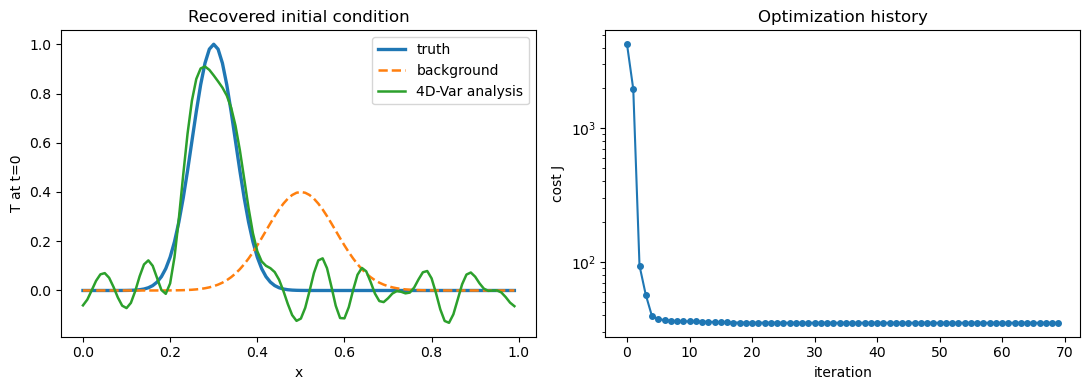

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(xgrid, x0_true, lw=2.4, label="truth")
ax[0].plot(xgrid, x_b, ls="--", lw=1.8, label="background")
ax[0].plot(xgrid, x0_analysis, lw=1.8, label="4D-Var analysis")
ax[0].set_xlabel("x")
ax[0].set_ylabel("T at t=0")
ax[0].set_title("Recovered initial condition")
ax[0].legend()

ax[1].semilogy(range(len(history)), history, marker="o", ms=4)
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("cost J")
ax[1].set_title("Optimization history")

fig.tight_layout()
plt.show()

**Takeaway:** the forward–adjoint–optimize loop is the point of this appendix; parameter estimation and additional diagnostics are intentionally omitted.